In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
regret_path= "../dataset/tpc-ds/regret_batch.csv"
regret_df = pd.read_csv(regret_path)

In [3]:
regret_df["batch_gap"] = regret_df["test_batch"] - regret_df["train_batch"]
regret_df["abs_batch_gap"] = regret_df["batch_gap"].abs()
regret_df["future_batch"] = regret_df["test_batch"] > regret_df["train_batch"]

In [4]:
def parse_ks_result(x):
    if pd.isna(x):
        return pd.Series({
            "ks_statistic": np.nan,
            "ks_pvalue": np.nan,
            "ks_location": np.nan,
            "ks_sign": np.nan,
        })
    x = str(x)
    statistic = re.search(r"statistic=np\.float\d+\(([-+eE0-9\.]+)\)", x)
    pvalue = re.search(r"pvalue=np\.float\d+\(([-+eE0-9\.]+)\)", x)
    location = re.search(r"statistic_location=np\.float\d+\(([-+eE0-9\.]+)\)", x)
    sign = re.search(r"statistic_sign=np\.int\d+\(([-+0-9]+)\)", x)
    return pd.Series({
        "ks_statistic": float(statistic.group(1)) if statistic else np.nan,
        "ks_pvalue": float(pvalue.group(1)) if pvalue else np.nan,
        "ks_location": float(location.group(1)) if location else np.nan,
        "ks_sign": int(sign.group(1)) if sign else np.nan,
    })
ks_cols = regret_df["ks_result"].apply(parse_ks_result)
regret_df = pd.concat([regret_df, ks_cols], axis=1)

In [5]:
import pandas as pd
from io import StringIO

def parse_pred_res_to_df(x):
    # 处理 NaN
    if pd.isna(x):
        return pd.DataFrame()

    # 转成字符串
    s = str(x)

    # 如果 CSV 里保存的是带 literal "\n" 的字符串，把它变成真正换行
    s = s.replace("\\n", "\n")

    # 去掉最后的 "[100 rows x 5 columns]"
    lines = []
    for line in s.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith("[") and "rows x" in line:
            continue
        if line.startswith(".."):
            continue
        lines.append(line)

    clean_s = "\n".join(lines)

    # 读取空格分隔的表格
    out = pd.read_csv(StringIO(clean_s), sep=r"\s+", engine="python")

    return out

In [6]:
pred_df = parse_pred_res_to_df(regret_df["pred_res"].iloc[0])
# pred_df.head()

In [7]:
def regret_summary_from_pred_res(x):
    pred_df = parse_pred_res_to_df(x)

    if pred_df.empty or "regret" not in pred_df.columns:
        return pd.Series({
            "regret_mean": pd.NA,
            "regret_median": pd.NA,
            "regret_p90": pd.NA,
            "regret_p95": pd.NA,
        })

    regret = pd.to_numeric(pred_df["regret"], errors="coerce")

    return pd.Series({
        "regret_mean": regret.mean(),
        "regret_median": regret.median(),
        "regret_p90": regret.quantile(0.90),
        "regret_p95": regret.quantile(0.95),
    })

regret_summary_cols = regret_df["pred_res"].apply(regret_summary_from_pred_res)

regret_df = pd.concat([regret_df, regret_summary_cols], axis=1)

In [8]:
# regret_df[[
#     "regret_mean",
#     "regret_median",
#     "regret_p90",
#     "regret_p95",
# ]].head()

In [9]:
corr_df = regret_df[
    [
        "mmd_score",
        "ks_statistic",
        "ks_pvalue",
        "ks_location",
        "ks_sign",
        "ws_score",
        "regret_mean",
        "regret_median",
        "regret_p90",
        "regret_p95",
    ]
].corr()

corr_df

,mmd_score,ks_statistic,ks_pvalue,ks_location,ks_sign,ws_score,regret_mean,regret_median,regret_p90,regret_p95
mmd_score,1.000000,0.669112,-0.514090,0.217358,-0.089411,0.660058,0.054589,0.031527,0.031364,0.054066
ks_statistic,0.669112,1.000000,-0.650427,0.253109,-0.079820,0.813335,0.007536,0.071033,0.006977,0.007627
ks_pvalue,-0.514090,-0.650427,1.000000,-0.464415,0.199072,-0.565934,-0.021122,-0.140174,-0.039213,-0.019289
ks_location,0.217358,0.253109,-0.464415,1.000000,0.126838,0.170458,0.058731,0.116769,0.069098,0.056520
ks_sign,-0.089411,-0.079820,0.199072,0.126838,1.000000,-0.184569,-0.048755,-0.010097,-0.031206,-0.049561
ws_score,0.660058,0.813335,-0.565934,0.170458,-0.184569,1.000000,-0.038821,0.035379,-0.019864,-0.039054
regret_mean,0.054589,0.007536,-0.021122,0.058731,-0.048755,-0.038821,1.000000,0.146967,0.827253,0.999241
regret_median,0.031527,0.071033,-0.140174,0.116769,-0.010097,0.035379,0.146967,1.000000,0.237760,0.139325
regret_p90,0.031364,0.006977,-0.039213,0.069098,-0.031206,-0.019864,0.827253,0.237760,1.000000,0.810300
regret_p95,0.054066,0.007627,-0.019289,0.056520,-0.049561,-0.039054,0.999241,0.139325,0.810300,1.000000


In [16]:
def plot_mmd_vs_regret(batch_df, save_path=None):
    plt.figure(figsize=(7, 5))

    plt.scatter(
        batch_df["mmd_score"],
        batch_df["regret_mean"],
        alpha=0.7
    )

    plt.xlabel("MMD Score")
    plt.ylabel("Mean Regret")
    plt.title("MMD Score vs Mean Regret")

    # correlation
    corr = batch_df["mmd_score"].corr(batch_df["regret_mean"])
    plt.text(
        0.05,
        0.95,
        f"Pearson r = {corr:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

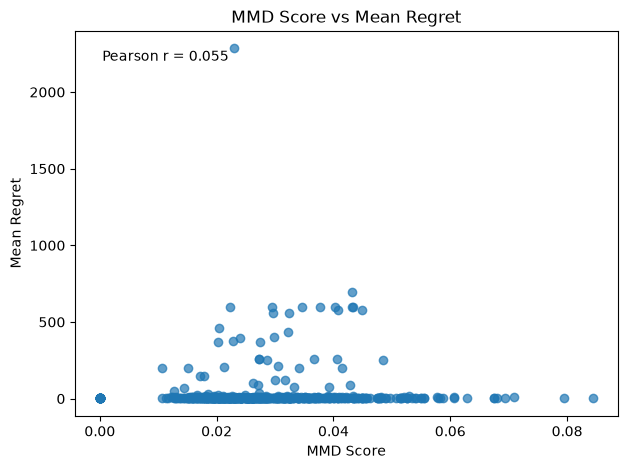

In [17]:
plot_mmd_vs_regret(
    regret_df,
    "../results/tpcds/mmd_vs_mean_regret.png"
)

In [18]:
def plot_mmd_vs_log_regret(batch_df, save_path=None):
    df = batch_df.copy()
    df["log_mean_regret"] = np.log1p(df["regret_mean"])

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df["mmd_score"],
        df["log_mean_regret"],
        alpha=0.7
    )

    plt.xlabel("MMD Score")
    plt.ylabel("log(1 + Mean Regret)")
    plt.title("MMD Score vs Log Mean Regret")

    corr = df["mmd_score"].corr(df["log_mean_regret"])
    plt.text(
        0.05,
        0.95,
        f"Pearson r = {corr:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

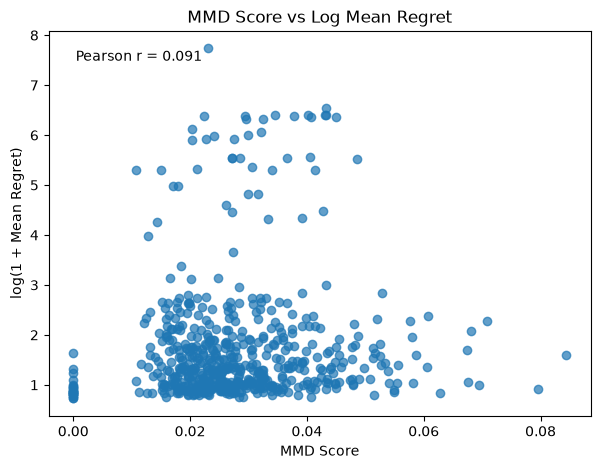

In [19]:
plot_mmd_vs_log_regret(
    regret_df,
    "../results/tpcds/mmd_vs_log_mean_regret.png"
)

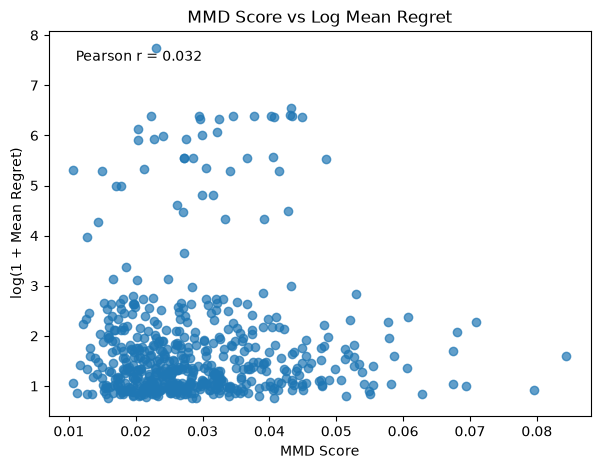

In [23]:
df_cross = regret_df[regret_df["same_batch"] == False].copy()
df_cross["log_mean_regret"] = np.log1p(df_cross["regret_mean"])

plot_mmd_vs_log_regret(df_cross)
# df_future = regret_df[regret_df["test_batch"] > regret_df["train_batch"]].copy()
# df_future["log_mean_regret"] = np.log1p(df_future["regret_mean"])
#
# plot_mmd_vs_log_regret(df_future)

In [26]:
df_mmd = regret_df["mmd_score"].copy()
df_mmd.describe()

count    576.000000
mean       0.027808
std        0.012535
min        0.000000
25%        0.020210
50%        0.026071
75%        0.034065
max        0.084431
Name: mmd_score, dtype: float64